# Оценка ручной разметки 1000 новостей против zero-shot пайплайна

Ноутбук:
- загружает ручной CSV датасет;
- делает EDA по разметке;
- прогоняет новости через RuBERT NLI zero-shot контур с тем же факторным каталогом;
- считает метрики применимости, выбора фактора, метки сигнала, числовых score;
- сравнивает ручные и предсказанные агрегаты, из которых строятся dashboard-графики.

Инференс кэшируется в `analysis_outputs/`, чтобы повторный запуск не пересчитывал модель.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import re
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    hamming_loss,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_fscore_support,
    r2_score,
)
from sklearn.preprocessing import MultiLabelBinarizer

ROOT = Path.cwd()
if not (ROOT / "manage.py").exists():
    ROOT = Path(r"C:\Users\whynot\VSCodeProjects\news-zero-shot")
sys.path.insert(0, str(ROOT))

DATASET_PATH = ROOT / "interfax_news_manual_factor_dataset_1000.csv"
OUTPUT_DIR = ROOT / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

DEFAULT_RELEVANCE_THRESHOLD = 0.20
CHECKPOINT = "cointegrated/rubert-base-cased-nli-threeway"
TEXT_CHUNK_SIZE = 32
PAIR_BATCH_SIZE = 128
USE_LOCAL_MODEL_ONLY = True

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)

print(f"project_root={ROOT}")
print(f"dataset={DATASET_PATH}")
print(f"output_dir={OUTPUT_DIR}")

project_root=C:\Users\whynot\VSCodeProjects\news-zero-shot
dataset=C:\Users\whynot\VSCodeProjects\news-zero-shot\interfax_news_manual_factor_dataset_1000.csv
output_dir=C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs


## 1. Загрузка и нормализация датасета

In [2]:
from analyzer.constants import BERT_MODEL_NAME, BERT_PROMPT_VERSION, normalize_factor_key
from analyzer.factors import FACTOR_CATALOG_VERSION, FACTOR_CONFIG
from analyzer.monitoring_service import compute_sentiment_score, label_from_score

COL = {
    "row_id": "Номер строки в датасете 1000",
    "batch": "Партия разметки",
    "source_row_id": "Номер новости в исходной выборке 1000",
    "section": "Раздел новости",
    "section_code": "Код раздела в исходном файле",
    "month": "Месяц публикации",
    "published_at": "Дата и время публикации",
    "title": "Заголовок новости",
    "description": "Описание новости",
    "first_paragraph": "Первый абзац новости",
    "full_text": "Полный текст новости",
    "url": "Ссылка на новость",
    "manual_applicable": "Фактор применим",
    "manual_factor": "Ключ основного фактора",
    "manual_factor_name": "Название основного фактора",
    "manual_factor_block": "Блок основного фактора",
    "manual_weight": "Вес основного фактора",
    "manual_additional_factors": "Дополнительные факторы",
    "manual_signal": "Метка сигнала",
    "manual_sentiment": "Числовая тональность",
    "manual_relevance": "Релевантность фактора от 0 до 1",
    "manual_pressure": "Давление риска от 0 до 1",
    "manual_confidence": "Уверенность разметчика от 0 до 1",
    "manual_evidence": "Фраза доказательство из новости",
    "needs_review": "Нужна повторная экспертная проверка",
    "annotation_status": "Статус ручной разметки",
    "catalog_version": "Версия факторного каталога",
}

raw_df = pd.read_csv(DATASET_PATH)
missing_columns = [name for name in COL.values() if name not in raw_df.columns]
if missing_columns:
    raise ValueError(f"В CSV не найдены ожидаемые колонки: {missing_columns}")

factor_df = pd.DataFrame(FACTOR_CONFIG)
factor_keys = factor_df["key"].tolist()
factor_weights = dict(zip(factor_df["key"], factor_df["weight"]))

def yes_no(value) -> bool:
    return str(value).strip().lower() in {"да", "yes", "true", "1", "y"}

def clean_text(value) -> str:
    if pd.isna(value):
        return ""
    return re.sub(r"\s+", " ", str(value)).strip()

def parse_additional_factors(value) -> list[str]:
    if pd.isna(value) or not str(value).strip():
        return []
    parsed = []
    for part in re.split(r"[;,\n|]+", str(value)):
        key = normalize_factor_key(part.strip())
        if key and key in factor_keys and key not in parsed:
            parsed.append(key)
    return parsed

def normalize_signal(value) -> str:
    label = str(value or "neutral").strip().lower()
    return label if label in {"positive", "negative", "neutral"} else "neutral"

df = raw_df.copy()
df["dataset_row_id"] = pd.to_numeric(df[COL["row_id"]], errors="raise").astype(int)
df["published_at"] = pd.to_datetime(df[COL["published_at"]], errors="coerce", utc=True)
df["published_date"] = df["published_at"].dt.date
df["manual_applicable_bool"] = df[COL["manual_applicable"]].map(yes_no)
df["manual_primary_factor"] = df[COL["manual_factor"]].map(lambda value: normalize_factor_key(str(value).strip()) if pd.notna(value) else None)
df["manual_primary_factor"] = df["manual_primary_factor"].fillna("not_relevant")
df["manual_signal_norm"] = df[COL["manual_signal"]].map(normalize_signal)
df["manual_sentiment_num"] = pd.to_numeric(df[COL["manual_sentiment"]], errors="coerce").fillna(0.0)
df["manual_relevance_num"] = pd.to_numeric(df[COL["manual_relevance"]], errors="coerce").fillna(0.0)
df["manual_pressure_num"] = pd.to_numeric(df[COL["manual_pressure"]], errors="coerce").fillna(0.0)
df["manual_confidence_num"] = pd.to_numeric(df[COL["manual_confidence"]], errors="coerce")
df["needs_review_bool"] = df[COL["needs_review"]].map(yes_no)
df["additional_factor_list"] = df[COL["manual_additional_factors"]].map(parse_additional_factors)

def manual_factor_set(row) -> list[str]:
    keys = []
    primary = row["manual_primary_factor"]
    if row["manual_applicable_bool"] and primary in factor_keys:
        keys.append(primary)
    for key in row["additional_factor_list"]:
        if key not in keys:
            keys.append(key)
    return keys

df["manual_factor_set"] = df.apply(manual_factor_set, axis=1)
df["manual_factor_count"] = df["manual_factor_set"].map(len)

full_text = df[COL["full_text"]].map(clean_text)
fallback_text = (
    df[COL["title"]].map(clean_text)
    + ". "
    + df[COL["description"]].map(clean_text)
    + ". "
    + df[COL["first_paragraph"]].map(clean_text)
).str.strip(". ")
df["eval_text"] = full_text.where(full_text.str.len() > 0, fallback_text)
df["eval_text_chars"] = df["eval_text"].str.len()

unknown_manual_keys = sorted(
    set(df.loc[df["manual_applicable_bool"], "manual_primary_factor"]) - set(factor_keys)
)
print(f"rows={len(df):,}, columns={len(raw_df.columns):,}")
print(f"active_factors={len(factor_keys)}, catalog_version={FACTOR_CATALOG_VERSION}")
print(f"unknown_manual_factor_keys={unknown_manual_keys}")
display(df[[
    "dataset_row_id",
    COL["title"],
    "manual_applicable_bool",
    "manual_primary_factor",
    "additional_factor_list",
    "manual_signal_norm",
    "manual_sentiment_num",
    "manual_relevance_num",
    "manual_pressure_num",
    "manual_confidence_num",
    "eval_text_chars",
]].head())

rows=1,000, columns=52
active_factors=36, catalog_version=social-risk-factors-v2
unknown_manual_factor_keys=[]


,dataset_row_id,Заголовок новости,manual_applicable_bool,manual_primary_factor,additional_factor_list,manual_signal_norm,manual_sentiment_num,manual_relevance_num,manual_pressure_num,manual_confidence_num,eval_text_chars
0,1,Путин поручил разработать план подъема двух затонувших в Черном море танкеров,True,air_pollution,[],negative,-1,0.9,0.85,0.90,897
1,2,Мозамбик пригласил российские компании добывать газ в стране,False,not_relevant,[],neutral,0,0.0,0.00,0.86,1730
2,3,Старт вечерней сессии на срочном рынке Мосбиржи задерживается,False,not_relevant,[],neutral,0,0.0,0.00,0.90,421
3,4,Аэропорты Волгограда и Краснодара приостановили работу,False,not_relevant,[],neutral,0,0.1,0.05,0.78,468
4,5,Шторм в Великобритании и Ирландии привел к сбоям в работе транспортной системы,False,not_relevant,[],neutral,0,0.1,0.05,0.78,839


## 2. EDA ручной разметки

,metric,value
0,rows,1000.0000
1,applicable_yes,725.0000
2,applicable_no,275.0000
3,unique_primary_factors,20.0000
4,rows_with_additional_factors,182.0000
5,rows_needing_review,99.0000
6,mean_manual_confidence,0.8042
7,mean_eval_text_chars,1565.0000


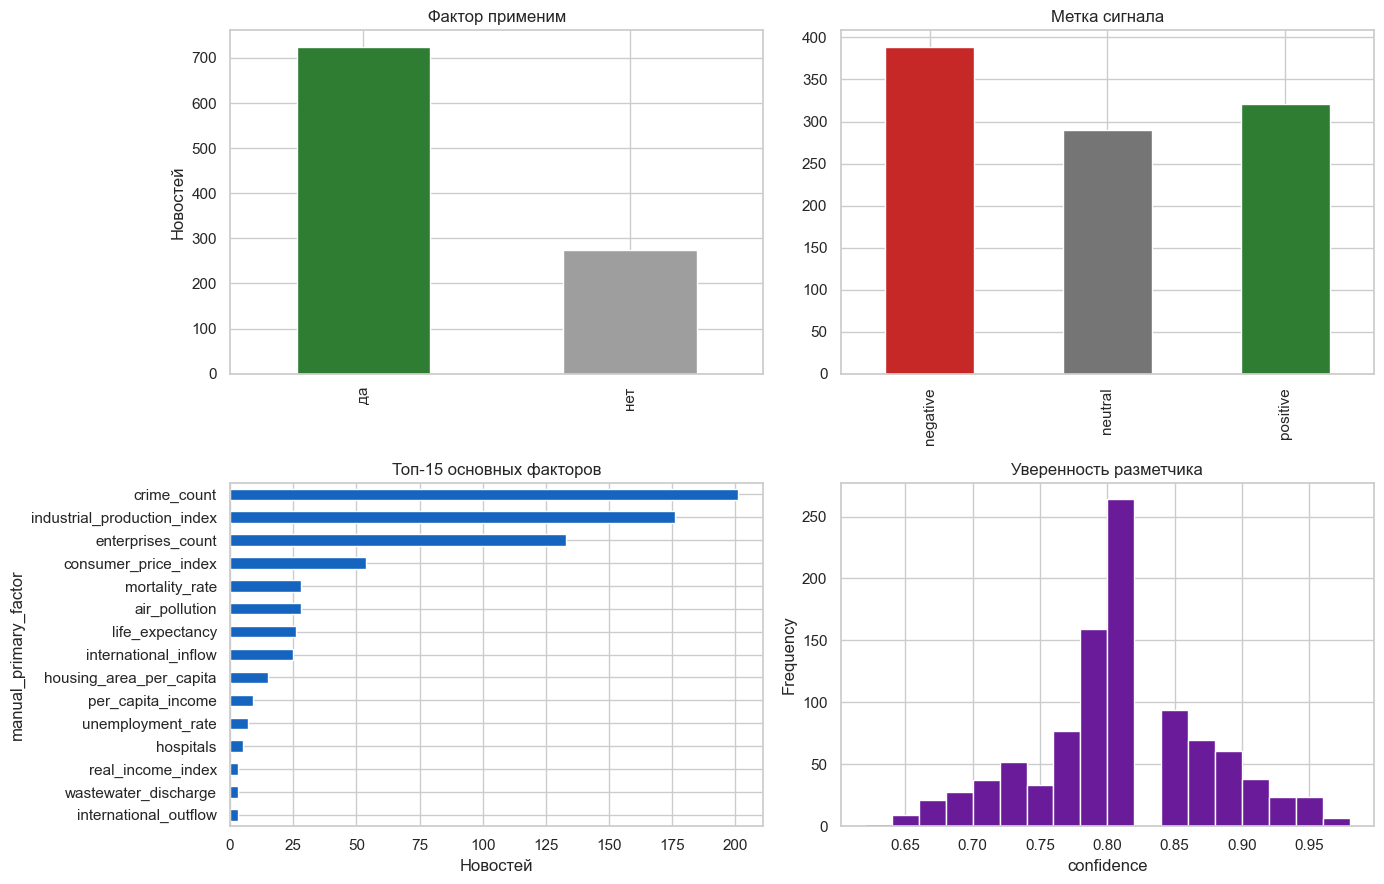

manual_signal_norm,negative,neutral,positive,All
Раздел новости,,,,
All,389,290,321,1000
В России,182,137,132,451
В мире,122,110,57,289
Экономика,82,40,127,249
Петербургский международный экономический форум,0,0,4,4
Москва,1,1,1,3
Цифровые технологии,1,1,0,2
Культура,0,1,0,1
Спорт,1,0,0,1


,news_count,negative_share,positive_share,mean_relevance,mean_pressure,mean_confidence
manual_primary_factor,,,,,,
crime_count,201,0.781,0.214,0.707,0.478,0.813
industrial_production_index,176,0.352,0.625,0.631,0.197,0.791
enterprises_count,133,0.323,0.647,0.591,0.152,0.769
consumer_price_index,54,0.611,0.315,0.644,0.336,0.786
air_pollution,28,0.607,0.393,0.739,0.470,0.824
mortality_rate,28,0.929,0.071,0.875,0.798,0.904
life_expectancy,26,0.538,0.462,0.690,0.321,0.819
international_inflow,25,0.400,0.600,0.664,0.234,0.797
housing_area_per_capita,15,0.467,0.467,0.690,0.367,0.824


In [3]:
eda_summary = pd.DataFrame(
    [
        ("rows", len(df)),
        ("applicable_yes", int(df["manual_applicable_bool"].sum())),
        ("applicable_no", int((~df["manual_applicable_bool"]).sum())),
        ("unique_primary_factors", int(df.loc[df["manual_applicable_bool"], "manual_primary_factor"].nunique())),
        ("rows_with_additional_factors", int(df["additional_factor_list"].map(bool).sum())),
        ("rows_needing_review", int(df["needs_review_bool"].sum())),
        ("mean_manual_confidence", round(float(df["manual_confidence_num"].mean()), 4)),
        ("mean_eval_text_chars", round(float(df["eval_text_chars"].mean()), 1)),
    ],
    columns=["metric", "value"],
)
display(eda_summary)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
df["manual_applicable_bool"].value_counts().rename(index={True: "да", False: "нет"}).plot(kind="bar", ax=axes[0, 0], color=["#2e7d32", "#9e9e9e"])
axes[0, 0].set_title("Фактор применим")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Новостей")

df["manual_signal_norm"].value_counts().reindex(["negative", "neutral", "positive"]).plot(kind="bar", ax=axes[0, 1], color=["#c62828", "#757575", "#2e7d32"])
axes[0, 1].set_title("Метка сигнала")
axes[0, 1].set_xlabel("")

df.loc[df["manual_applicable_bool"], "manual_primary_factor"].value_counts().head(15).sort_values().plot(kind="barh", ax=axes[1, 0], color="#1565c0")
axes[1, 0].set_title("Топ-15 основных факторов")
axes[1, 0].set_xlabel("Новостей")

df["manual_confidence_num"].plot(kind="hist", bins=18, ax=axes[1, 1], color="#6a1b9a")
axes[1, 1].set_title("Уверенность разметчика")
axes[1, 1].set_xlabel("confidence")

plt.tight_layout()
plt.show()

display(pd.crosstab(df[COL["section"]], df["manual_signal_norm"], margins=True).sort_values("All", ascending=False).head(20))
display(
    df.loc[df["manual_applicable_bool"]]
    .groupby("manual_primary_factor")
    .agg(
        news_count=("dataset_row_id", "count"),
        negative_share=("manual_signal_norm", lambda s: round((s == "negative").mean(), 3)),
        positive_share=("manual_signal_norm", lambda s: round((s == "positive").mean(), 3)),
        mean_relevance=("manual_relevance_num", "mean"),
        mean_pressure=("manual_pressure_num", "mean"),
        mean_confidence=("manual_confidence_num", "mean"),
    )
    .sort_values("news_count", ascending=False)
    .head(20)
    .round(3)
)

## 3. BERT zero-shot инференс на полном тексте

In [4]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

text_hash = hashlib.sha256("\n".join(df["eval_text"].tolist()).encode("utf-8")).hexdigest()[:12]
cache_path = OUTPUT_DIR / f"manual_dataset_bert_predictions_full_text_{text_hash}.csv"
expected_prediction_rows = len(df) * len(factor_keys)

def cache_is_valid(path: Path) -> bool:
    if not path.exists():
        return False
    try:
        cached_head = pd.read_csv(path, nrows=5)
        if not {"dataset_row_id", "factor_key", "sentiment_score"}.issubset(cached_head.columns):
            return False
        cached_rows = sum(1 for _ in open(path, "r", encoding="utf-8")) - 1
        return cached_rows == expected_prediction_rows
    except Exception:
        return False

def load_model():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"device={device}, checkpoint={CHECKPOINT}")
    tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT, local_files_only=USE_LOCAL_MODEL_ONLY)
    model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT, local_files_only=USE_LOCAL_MODEL_ONLY)
    model.to(device)
    model.eval()
    entailment_index = model.config.label2id["entailment"]
    return tokenizer, model, device, entailment_index

def predict_entailment_matrix(texts: list[str], label_texts: list[str]) -> np.ndarray:
    tokenizer, model, device, entailment_index = load_model()
    matrices = []
    started = time.time()
    for text_start in range(0, len(texts), TEXT_CHUNK_SIZE):
        chunk_texts = texts[text_start : text_start + TEXT_CHUNK_SIZE]
        premises, hypotheses = [], []
        for text in chunk_texts:
            premises.extend([text] * len(label_texts))
            hypotheses.extend(label_texts)

        outputs = []
        for pair_start in range(0, len(premises), PAIR_BATCH_SIZE):
            encoded = tokenizer(
                premises[pair_start : pair_start + PAIR_BATCH_SIZE],
                hypotheses[pair_start : pair_start + PAIR_BATCH_SIZE],
                truncation=True,
                return_tensors="pt",
                padding=True,
            )
            encoded = {key: value.to(device) for key, value in encoded.items()}
            with torch.inference_mode():
                logits = model(**encoded).logits
                probs = torch.softmax(logits, dim=-1)[:, entailment_index]
            outputs.append(probs.detach().cpu())

        chunk_matrix = torch.cat(outputs).numpy().reshape(len(chunk_texts), len(label_texts))
        matrices.append(chunk_matrix)
        done = min(text_start + len(chunk_texts), len(texts))
        elapsed = time.time() - started
        print(f"processed {done:4d}/{len(texts)} texts; elapsed={elapsed:,.1f}s")

    if device == "cuda":
        torch.cuda.empty_cache()
    return np.vstack(matrices)

label_texts = []
for item in FACTOR_CONFIG:
    label_texts.extend([item["positive_label"], item["negative_label"]])

if cache_is_valid(cache_path):
    pred_long = pd.read_csv(cache_path)
    print(f"Loaded cached predictions: {cache_path}")
else:
    raw_matrix = predict_entailment_matrix(df["eval_text"].tolist(), label_texts)
    records = []
    row_ids = df["dataset_row_id"].to_numpy()
    for factor_idx, factor in enumerate(FACTOR_CONFIG):
        positive_raw = raw_matrix[:, 2 * factor_idx].astype(float)
        negative_raw = raw_matrix[:, 2 * factor_idx + 1].astype(float)
        total = positive_raw + negative_raw
        positive_probability = np.divide(positive_raw, total, out=np.full_like(positive_raw, 0.5), where=total > 0)
        negative_probability = np.divide(negative_raw, total, out=np.full_like(negative_raw, 0.5), where=total > 0)
        sentiment_score = positive_probability - negative_probability
        for row_id, pos, neg, score in zip(row_ids, positive_probability, negative_probability, sentiment_score):
            records.append(
                {
                    "dataset_row_id": int(row_id),
                    "factor_key": factor["key"],
                    "factor_name": factor["name"],
                    "positive_probability": float(pos),
                    "negative_probability": float(neg),
                    "sentiment_score": float(score),
                    "relevance": float(abs(score)),
                    "pressure": float(max(-score, 0.0)),
                    "confidence": float(max(pos, neg)),
                }
            )
    pred_long = pd.DataFrame.from_records(records)
    pred_long.to_csv(cache_path, index=False, encoding="utf-8")
    print(f"Saved predictions: {cache_path}")

pred_long["pred_label"] = pred_long["sentiment_score"].map(lambda value: label_from_score(value, DEFAULT_RELEVANCE_THRESHOLD))
pred_long["pred_is_relevant"] = pred_long["relevance"] >= DEFAULT_RELEVANCE_THRESHOLD
display(pred_long.head())
print(f"prediction_rows={len(pred_long):,}, expected={expected_prediction_rows:,}")

device=cuda, checkpoint=cointegrated/rubert-base-cased-nli-threeway


processed   32/1000 texts; elapsed=13.4s


processed   64/1000 texts; elapsed=29.6s


processed   96/1000 texts; elapsed=43.5s


processed  128/1000 texts; elapsed=58.8s


...

processed  992/1000 texts; elapsed=435.9s


processed 1000/1000 texts; elapsed=445.9s


Saved predictions: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_bert_predictions_full_text_5df03950348d.csv


,dataset_row_id,factor_key,factor_name,positive_probability,negative_probability,sentiment_score,relevance,pressure,confidence,pred_label,pred_is_relevant
0,1,population_size,Численность населения,0.679098,0.320902,0.358197,0.358197,0.000000,0.679098,positive,True
1,2,population_size,Численность населения,0.605275,0.394725,0.210550,0.210550,0.000000,0.605275,positive,True
2,3,population_size,Численность населения,0.662819,0.337181,0.325637,0.325637,0.000000,0.662819,positive,True
3,4,population_size,Численность населения,0.650723,0.349277,0.301447,0.301447,0.000000,0.650723,positive,True
4,5,population_size,Численность населения,0.356183,0.643817,-0.287634,0.287634,0.287634,0.643817,negative,True


prediction_rows=36,000, expected=36,000


## 4. Подготовка предсказаний к метрикам

In [5]:
score_matrix = (
    pred_long.pivot(index="dataset_row_id", columns="factor_key", values="relevance")
    .reindex(index=df["dataset_row_id"], columns=factor_keys)
    .fillna(0.0)
)
sentiment_matrix = (
    pred_long.pivot(index="dataset_row_id", columns="factor_key", values="sentiment_score")
    .reindex(index=df["dataset_row_id"], columns=factor_keys)
    .fillna(0.0)
)
label_matrix = (
    pred_long.pivot(index="dataset_row_id", columns="factor_key", values="pred_label")
    .reindex(index=df["dataset_row_id"], columns=factor_keys)
    .fillna("neutral")
)
pressure_matrix = (
    pred_long.pivot(index="dataset_row_id", columns="factor_key", values="pressure")
    .reindex(index=df["dataset_row_id"], columns=factor_keys)
    .fillna(0.0)
)
confidence_matrix = (
    pred_long.pivot(index="dataset_row_id", columns="factor_key", values="confidence")
    .reindex(index=df["dataset_row_id"], columns=factor_keys)
    .fillna(0.0)
)

ranked = pred_long.sort_values(["dataset_row_id", "relevance"], ascending=[True, False])
top5 = ranked.groupby("dataset_row_id").head(5)
pred_primary = top5.groupby("dataset_row_id").first()[["factor_key", "relevance", "sentiment_score", "pred_label"]]
pred_top_lists = top5.groupby("dataset_row_id")["factor_key"].agg(list).rename("pred_top5_factors")
pred_any_relevant = score_matrix.ge(DEFAULT_RELEVANCE_THRESHOLD).any(axis=1).rename("pred_any_relevant")

eval_df = df.set_index("dataset_row_id").join(pred_primary.add_prefix("pred_primary_"))
eval_df = eval_df.join(pred_top_lists).join(pred_any_relevant)
eval_df["pred_primary_factor_key"] = np.where(
    eval_df["pred_any_relevant"],
    eval_df["pred_primary_factor_key"],
    "not_relevant",
)

def in_top_k(row, k: int) -> bool:
    return row["manual_primary_factor"] in (row["pred_top5_factors"] or [])[:k]

applicable_eval = eval_df[eval_df["manual_applicable_bool"] & eval_df["manual_primary_factor"].isin(factor_keys)].copy()
applicable_eval["manual_in_top1"] = applicable_eval["manual_primary_factor"] == applicable_eval["pred_primary_factor_key"]
applicable_eval["manual_in_top3"] = applicable_eval.apply(lambda row: in_top_k(row, 3), axis=1)
applicable_eval["manual_in_top5"] = applicable_eval.apply(lambda row: in_top_k(row, 5), axis=1)

manual_factor_pred = (
    applicable_eval.reset_index()[["dataset_row_id", "manual_primary_factor", "manual_signal_norm", "manual_sentiment_num", "manual_relevance_num", "manual_pressure_num"]]
    .merge(
        pred_long,
        left_on=["dataset_row_id", "manual_primary_factor"],
        right_on=["dataset_row_id", "factor_key"],
        how="left",
    )
)

display(eval_df[[
    COL["title"],
    "manual_applicable_bool",
    "manual_primary_factor",
    "manual_signal_norm",
    "pred_any_relevant",
    "pred_primary_factor_key",
    "pred_primary_relevance",
    "pred_primary_pred_label",
    "pred_top5_factors",
]].head(10))

,Заголовок новости,manual_applicable_bool,manual_primary_factor,manual_signal_norm,pred_any_relevant,pred_primary_factor_key,pred_primary_relevance,pred_primary_pred_label,pred_top5_factors
dataset_row_id,,,,,,,,,
1,Путин поручил разработать план подъема двух затонувших в Черном море танкеров,True,air_pollution,negative,True,child_living_wage,0.972190,negative,"[child_living_wage, living_wage, housing_area_per_capita, large_families_housing, enterprises_count]"
2,Мозамбик пригласил российские компании добывать газ в стране,False,not_relevant,neutral,True,crime_count,0.994901,positive,"[crime_count, hospitals, marriage_rate, housing_area_per_capita, living_wage]"
3,Старт вечерней сессии на срочном рынке Мосбиржи задерживается,False,not_relevant,neutral,True,enterprises_count,0.964488,negative,"[enterprises_count, internal_arrivals, living_wage, housing_area_per_capita, life_expectancy]"
4,Аэропорты Волгограда и Краснодара приостановили работу,False,not_relevant,neutral,True,internal_arrivals,0.824157,negative,"[internal_arrivals, enterprises_count, housing_area_per_capita, child_living_wage, internal_departures]"
5,Шторм в Великобритании и Ирландии привел к сбоям в работе транспортной системы,False,not_relevant,neutral,True,divorce_rate,0.956432,positive,"[divorce_rate, child_living_wage, hospitals, enterprises_count, international_inflow]"
6,Консерватор Каст одержал победу на выборах президента Чили,False,not_relevant,neutral,True,hospitals,0.973087,negative,"[hospitals, female_population, qualified_doctors, child_living_wage, mortality_rate]"
7,Женщина погибла в результате атаки беспилотников ВСУ на населенный пункт Вахрушево в ЛНР,True,crime_count,negative,True,living_wage,0.960424,positive,"[living_wage, enterprises_count, childcare_allowance, male_population, life_expectancy]"
8,"Скидки на нефть Urals и ESPO в мае упали на $0,6-1 за баррель к апрелю",False,not_relevant,neutral,True,primary_housing_price_index,0.966119,negative,"[primary_housing_price_index, divorce_rate, consumer_price_index, housing_area_per_capita, secondary_housing_price_index]"
9,В посольстве РФ рассказали о планах Британии отказаться от российского урана к 2028 году,False,not_relevant,neutral,True,divorce_rate,0.952483,positive,"[divorce_rate, marriage_rate, male_population, international_inflow, consumer_price_index]"


## 5. Метрики качества классификации

In [6]:
def binary_metric_row(name: str, y_true, y_pred) -> dict:
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    return {
        "metric_group": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support_positive": int(np.sum(y_true)),
    }

y_app_true = eval_df["manual_applicable_bool"].astype(int)
y_app_pred = eval_df["pred_any_relevant"].astype(int)
applicability_metrics = pd.DataFrame([binary_metric_row("applicability_any_factor", y_app_true, y_app_pred)])
app_confusion = pd.DataFrame(
    confusion_matrix(y_app_true, y_app_pred, labels=[0, 1]),
    index=["true_not_relevant", "true_relevant"],
    columns=["pred_not_relevant", "pred_relevant"],
)

mlb = MultiLabelBinarizer(classes=factor_keys)
y_factor_true = mlb.fit_transform(df["manual_factor_set"])
y_factor_pred = score_matrix.ge(DEFAULT_RELEVANCE_THRESHOLD).astype(int).to_numpy()
factor_metric_rows = []
for average in ["micro", "macro", "weighted", "samples"]:
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_factor_true, y_factor_pred, average=average, zero_division=0
    )
    factor_metric_rows.append(
        {
            "average": average,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        }
    )
factor_metrics = pd.DataFrame(factor_metric_rows)
factor_metrics["hamming_loss"] = hamming_loss(y_factor_true, y_factor_pred)
factor_metrics["subset_accuracy"] = accuracy_score(y_factor_true, y_factor_pred)

primary_factor_metrics = pd.DataFrame(
    [
        {
            "metric": "primary_factor_top1_accuracy",
            "value": applicable_eval["manual_in_top1"].mean(),
            "n": len(applicable_eval),
        },
        {
            "metric": "primary_factor_top3_hit_rate",
            "value": applicable_eval["manual_in_top3"].mean(),
            "n": len(applicable_eval),
        },
        {
            "metric": "primary_factor_top5_hit_rate",
            "value": applicable_eval["manual_in_top5"].mean(),
            "n": len(applicable_eval),
        },
        {
            "metric": "primary_factor_macro_f1",
            "value": f1_score(
                applicable_eval["manual_primary_factor"],
                applicable_eval["pred_primary_factor_key"],
                average="macro",
                zero_division=0,
            ),
            "n": len(applicable_eval),
        },
    ]
)

signal_labels = ["negative", "neutral", "positive"]
signal_accuracy = accuracy_score(manual_factor_pred["manual_signal_norm"], manual_factor_pred["pred_label"])
signal_macro_f1 = f1_score(
    manual_factor_pred["manual_signal_norm"],
    manual_factor_pred["pred_label"],
    labels=signal_labels,
    average="macro",
    zero_division=0,
)
signal_metrics = pd.DataFrame(
    [
        {"metric": "signal_on_true_factor_accuracy", "value": signal_accuracy, "n": len(manual_factor_pred)},
        {"metric": "signal_on_true_factor_macro_f1", "value": signal_macro_f1, "n": len(manual_factor_pred)},
    ]
)
signal_confusion = pd.DataFrame(
    confusion_matrix(
        manual_factor_pred["manual_signal_norm"],
        manual_factor_pred["pred_label"],
        labels=signal_labels,
    ),
    index=[f"true_{label}" for label in signal_labels],
    columns=[f"pred_{label}" for label in signal_labels],
)

display(applicability_metrics.round(4))
display(app_confusion)
display(factor_metrics.round(4))
display(primary_factor_metrics.round(4))
display(signal_metrics.round(4))
display(signal_confusion)

primary_report = pd.DataFrame(
    classification_report(
        applicable_eval["manual_primary_factor"],
        applicable_eval["pred_primary_factor_key"],
        zero_division=0,
        output_dict=True,
    )
).T
display(primary_report.sort_values("support", ascending=False).head(20).round(3))

,metric_group,accuracy,precision,recall,f1,support_positive
0,applicability_any_factor,0.725,0.725,1.0,0.8406,725


,pred_not_relevant,pred_relevant
true_not_relevant,0,275
true_relevant,0,725


,average,precision,recall,f1,hamming_loss,subset_accuracy
0,micro,0.0343,0.7639,0.0656,0.5532,0.0
1,macro,0.0351,0.4972,0.0567,0.5532,0.0
2,weighted,0.1956,0.7639,0.2923,0.5532,0.0
3,samples,0.0334,0.5513,0.0625,0.5532,0.0


,metric,value,n
0,primary_factor_top1_accuracy,0.0814,725
1,primary_factor_top3_hit_rate,0.2359,725
2,primary_factor_top5_hit_rate,0.3338,725
3,primary_factor_macro_f1,0.0298,725


,metric,value,n
0,signal_on_true_factor_accuracy,0.3959,725
1,signal_on_true_factor_macro_f1,0.3081,725


,pred_negative,pred_neutral,pred_positive
true_negative,117,99,173
true_neutral,8,3,4
true_positive,87,67,167


,precision,recall,f1-score,support
weighted avg,0.395,0.081,0.128,725.0
macro avg,0.070,0.026,0.030,725.0
crime_count,0.516,0.080,0.138,201.0
industrial_production_index,0.679,0.108,0.186,176.0
enterprises_count,0.189,0.075,0.108,133.0
consumer_price_index,0.600,0.167,0.261,54.0
mortality_rate,0.000,0.000,0.000,28.0
air_pollution,0.000,0.000,0.000,28.0
life_expectancy,0.000,0.000,0.000,26.0
international_inflow,0.182,0.080,0.111,25.0


## 6. Метрики числовых оценок и подбор порога релевантности

,target,mae,rmse,r2,pearson,spearman
0,sentiment_score_on_true_factor,0.9476,1.1384,-0.3354,0.0879,0.0921
1,relevance_on_true_factor,0.3124,0.3721,-6.2331,0.0772,0.0861
2,pressure_on_true_factor,0.3596,0.4572,-1.5987,-0.0269,-0.0549


Best threshold by factor micro-F1:


,value
threshold,0.900000
factor_micro_precision,0.073387
factor_micro_recall,0.198907
factor_micro_f1,0.107216
factor_macro_f1,0.075503
applicability_precision,0.730337
applicability_recall,0.896552
applicability_f1,0.804954
predicted_relevant_pairs,2480.000000


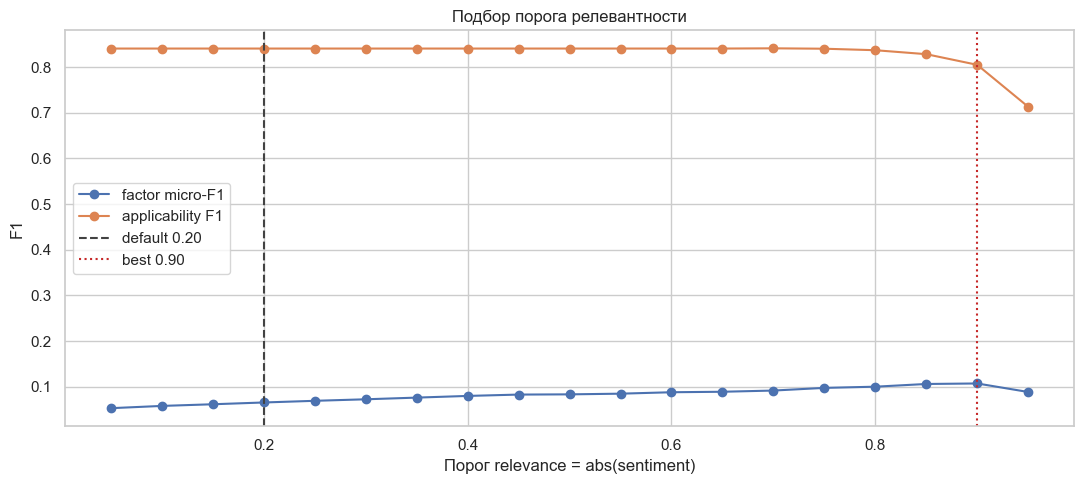

,threshold,factor_micro_precision,factor_micro_recall,factor_micro_f1,factor_macro_f1,applicability_precision,applicability_recall,applicability_f1,predicted_relevant_pairs
0,0.05,0.0273,0.9169,0.0531,0.0472,0.7250,1.0000,0.8406,30683
1,0.10,0.0300,0.8634,0.0581,0.0514,0.7250,1.0000,0.8406,26300
2,0.15,0.0321,0.8055,0.0617,0.0539,0.7250,1.0000,0.8406,22976
3,0.20,0.0343,0.7639,0.0656,0.0567,0.7250,1.0000,0.8406,20399
4,0.25,0.0364,0.7257,0.0692,0.0591,0.7250,1.0000,0.8406,18265
5,0.30,0.0383,0.6896,0.0726,0.0609,0.7250,1.0000,0.8406,16476
6,0.35,0.0405,0.6590,0.0763,0.0631,0.7250,1.0000,0.8406,14901
7,0.40,0.0427,0.6273,0.0799,0.0656,0.7250,1.0000,0.8406,13447
8,0.45,0.0446,0.5902,0.0829,0.0677,0.7250,1.0000,0.8406,12114
9,0.50,0.0452,0.5355,0.0834,0.0682,0.7250,1.0000,0.8406,10840


In [7]:
def regression_metrics(y_true, y_pred, name: str) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "target": name,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": math.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan,
        "pearson": pd.Series(y_true).corr(pd.Series(y_pred), method="pearson"),
        "spearman": pd.Series(y_true).corr(pd.Series(y_pred), method="spearman"),
    }

regression_table = pd.DataFrame(
    [
        regression_metrics(
            manual_factor_pred["manual_sentiment_num"],
            manual_factor_pred["sentiment_score"],
            "sentiment_score_on_true_factor",
        ),
        regression_metrics(
            manual_factor_pred["manual_relevance_num"],
            manual_factor_pred["relevance"],
            "relevance_on_true_factor",
        ),
        regression_metrics(
            manual_factor_pred["manual_pressure_num"],
            manual_factor_pred["pressure"],
            "pressure_on_true_factor",
        ),
    ]
)
display(regression_table.round(4))

thresholds = np.round(np.arange(0.05, 0.96, 0.05), 2)
sweep_rows = []
for threshold in thresholds:
    y_pred_factor = score_matrix.ge(threshold).astype(int).to_numpy()
    micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
        y_factor_true, y_pred_factor, average="micro", zero_division=0
    )
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_factor_true, y_pred_factor, average="macro", zero_division=0
    )
    y_pred_any = score_matrix.ge(threshold).any(axis=1).astype(int)
    app_precision, app_recall, app_f1, _ = precision_recall_fscore_support(
        y_app_true, y_pred_any, average="binary", zero_division=0
    )
    sweep_rows.append(
        {
            "threshold": threshold,
            "factor_micro_precision": micro_precision,
            "factor_micro_recall": micro_recall,
            "factor_micro_f1": micro_f1,
            "factor_macro_f1": macro_f1,
            "applicability_precision": app_precision,
            "applicability_recall": app_recall,
            "applicability_f1": app_f1,
            "predicted_relevant_pairs": int(y_pred_factor.sum()),
        }
    )
threshold_sweep = pd.DataFrame(sweep_rows)
best_threshold = threshold_sweep.sort_values("factor_micro_f1", ascending=False).iloc[0]
print("Best threshold by factor micro-F1:")
display(best_threshold.to_frame("value"))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(threshold_sweep["threshold"], threshold_sweep["factor_micro_f1"], marker="o", label="factor micro-F1")
ax.plot(threshold_sweep["threshold"], threshold_sweep["applicability_f1"], marker="o", label="applicability F1")
ax.axvline(DEFAULT_RELEVANCE_THRESHOLD, color="#424242", linestyle="--", label=f"default {DEFAULT_RELEVANCE_THRESHOLD:.2f}")
ax.axvline(best_threshold["threshold"], color="#c62828", linestyle=":", label=f"best {best_threshold['threshold']:.2f}")
ax.set_xlabel("Порог relevance = abs(sentiment)")
ax.set_ylabel("F1")
ax.set_title("Подбор порога релевантности")
ax.legend()
plt.tight_layout()
plt.show()

display(threshold_sweep.round(4))

## 7. Сравнение агрегатов dashboard-графиков

C:\Users\whynot\AppData\Local\Temp\ipykernel_8508\3261588430.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  manual_long["is_relevant"] = manual_long["is_relevant"].fillna(False).astype(bool)


,target,mae,rmse,r2,pearson,spearman
0,daily_average_sentiment,0.0972,0.1158,-12.0397,0.2166,0.2025
1,daily_risk_index,0.1171,0.1284,-32.2171,0.1568,0.1403
2,factor_date_average_sentiment,0.3845,0.5105,-5.3098,-0.0074,-0.0121
3,factor_date_relevant_news_count,1.5535,2.0689,-53.7825,0.1264,0.1169


,manual_relevant_total,pred_relevant_total,sentiment_mae,relevant_count_mae
factor_key,,,,
crime_count,201,715,0.797,1.531
industrial_production_index,176,426,0.472,0.859
enterprises_count,133,824,0.629,1.975
consumer_price_index,54,481,0.358,1.218
air_pollution,28,665,0.401,1.805
mortality_rate,28,288,0.312,0.768
life_expectancy,26,652,0.387,1.791
international_inflow,25,455,0.328,1.226
housing_area_per_capita,15,985,0.812,2.740


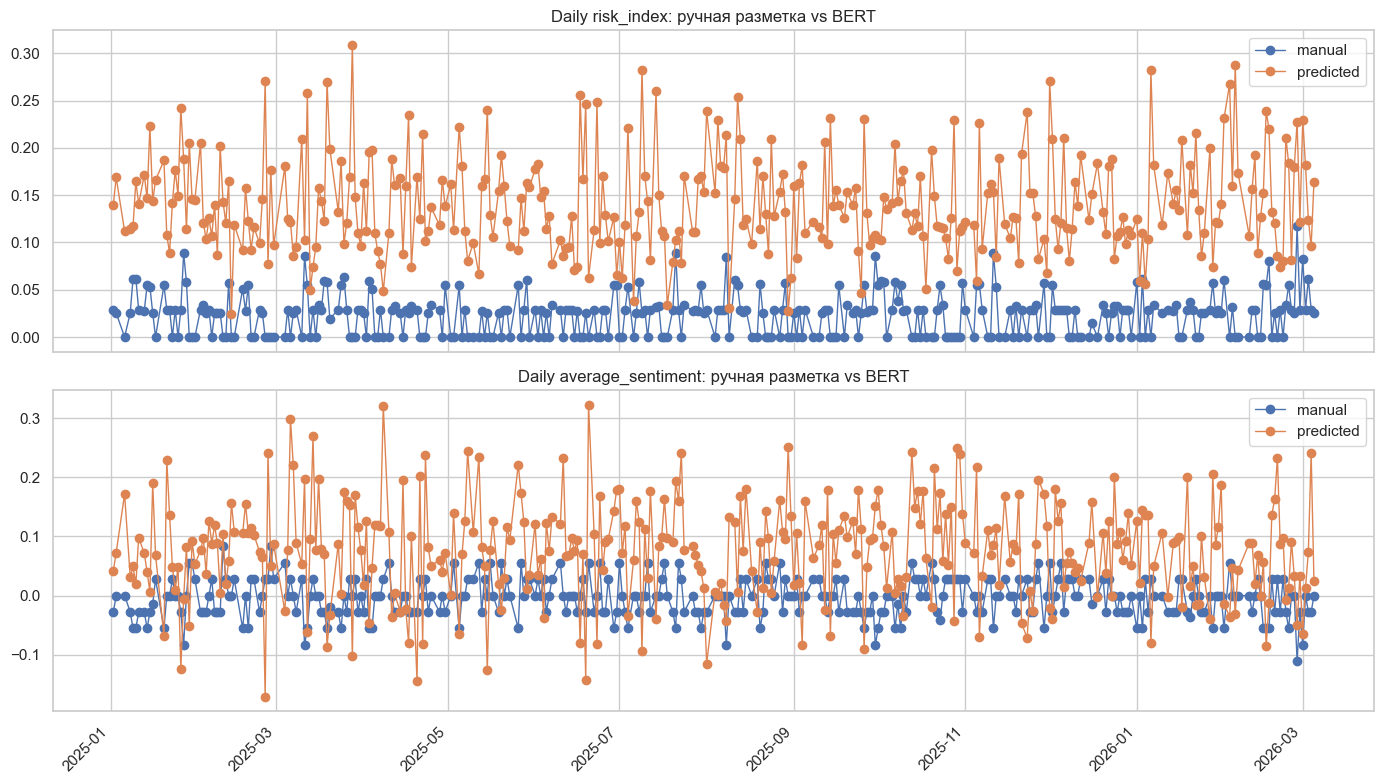

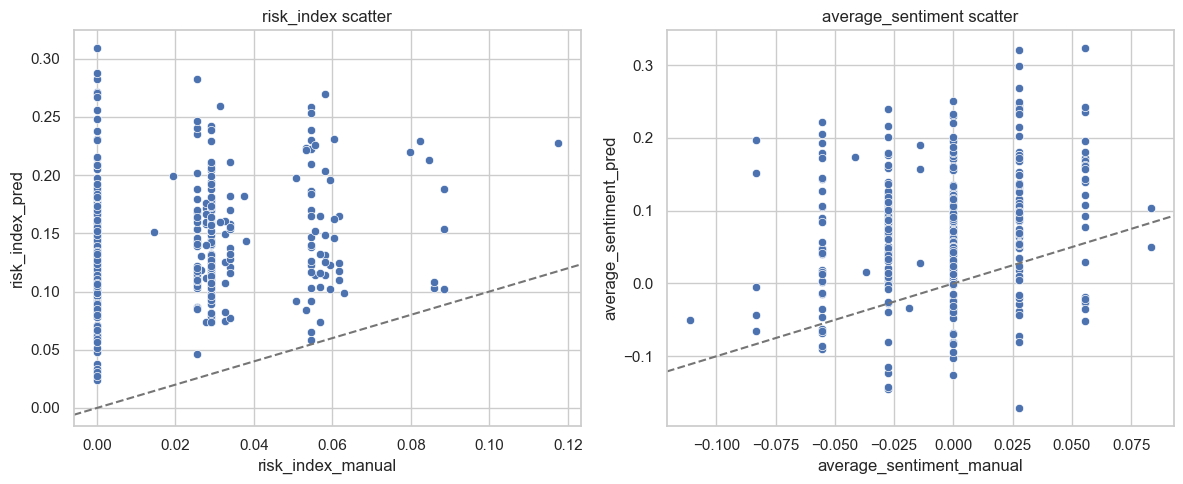

In [8]:
dates = sorted(df["published_date"].dropna().unique())
date_factor_index = pd.MultiIndex.from_product([dates, factor_keys], names=["published_date", "factor_key"])

manual_main_long = df.loc[
    df["manual_applicable_bool"] & df["manual_primary_factor"].isin(factor_keys),
    ["dataset_row_id", "published_date", "manual_primary_factor", "manual_sentiment_num", "manual_signal_norm"],
].rename(
    columns={
        "manual_primary_factor": "factor_key",
        "manual_sentiment_num": "sentiment_score",
        "manual_signal_norm": "sentiment_label",
    }
)
manual_main_long["is_relevant"] = True

manual_long = (
    pd.MultiIndex.from_product([df["dataset_row_id"], factor_keys], names=["dataset_row_id", "factor_key"])
    .to_frame(index=False)
    .merge(df.set_index("dataset_row_id")[["published_date"]], left_on="dataset_row_id", right_index=True, how="left")
    .merge(
        manual_main_long[["dataset_row_id", "factor_key", "sentiment_score", "sentiment_label", "is_relevant"]],
        on=["dataset_row_id", "factor_key"],
        how="left",
    )
)
manual_long["sentiment_score"] = manual_long["sentiment_score"].fillna(0.0)
manual_long["sentiment_label"] = manual_long["sentiment_label"].fillna("neutral")
manual_long["is_relevant"] = manual_long["is_relevant"].fillna(False).astype(bool)

predicted_long = pred_long.merge(
    df.set_index("dataset_row_id")[["published_date"]],
    left_on="dataset_row_id",
    right_index=True,
    how="left",
).rename(columns={"pred_label": "sentiment_label", "pred_is_relevant": "is_relevant"})

def aggregate_like_dashboard(long_df: pd.DataFrame, score_col: str = "sentiment_score") -> tuple[pd.DataFrame, pd.DataFrame]:
    total_news_by_date = df.groupby("published_date")["dataset_row_id"].nunique().rename("news_count")
    relevant = long_df[long_df["is_relevant"]].copy()

    avg_sentiment = relevant.groupby(["published_date", "factor_key"])[score_col].mean().rename("average_sentiment")
    relevant_counts = relevant.groupby(["published_date", "factor_key"])["dataset_row_id"].nunique().rename("relevant_news_count")
    positive_hits = relevant[relevant["sentiment_label"] == "positive"].groupby(["published_date", "factor_key"]).size().rename("positive_hits")
    negative_hits = relevant[relevant["sentiment_label"] == "negative"].groupby(["published_date", "factor_key"]).size().rename("negative_hits")
    neutral_hits = long_df[long_df["sentiment_label"] == "neutral"].groupby(["published_date", "factor_key"]).size().rename("neutral_hits")

    factor_daily = pd.DataFrame(index=date_factor_index).join(
        [avg_sentiment, relevant_counts, positive_hits, negative_hits, neutral_hits]
    ).fillna(0.0).reset_index()
    factor_daily["relevant_news_count"] = factor_daily["relevant_news_count"].astype(int)
    factor_daily["positive_hits"] = factor_daily["positive_hits"].astype(int)
    factor_daily["negative_hits"] = factor_daily["negative_hits"].astype(int)
    factor_daily["neutral_hits"] = factor_daily["neutral_hits"].astype(int)
    factor_daily["weight"] = factor_daily["factor_key"].map(factor_weights).astype(float)

    daily_records = []
    total_weight = factor_df["weight"].sum()
    for day, items in factor_daily.groupby("published_date"):
        average_sentiment = items["average_sentiment"].mean()
        risk_index = (np.maximum(-items["average_sentiment"], 0.0) * items["weight"]).sum() / total_weight
        daily_records.append(
            {
                "published_date": day,
                "average_sentiment": average_sentiment,
                "risk_index": risk_index,
                "news_count": int(total_news_by_date.get(day, 0)),
                "factor_count": len(items),
            }
        )
    daily = pd.DataFrame(daily_records).sort_values("published_date")
    daily["delta_from_previous"] = daily["average_sentiment"].diff().fillna(0.0)
    factor_daily["delta_from_previous"] = factor_daily.sort_values(["factor_key", "published_date"]).groupby("factor_key")["average_sentiment"].diff().fillna(0.0)
    return daily, factor_daily

manual_daily, manual_factor_daily = aggregate_like_dashboard(manual_long)
pred_daily, pred_factor_daily = aggregate_like_dashboard(predicted_long)

daily_compare = manual_daily.merge(pred_daily, on="published_date", suffixes=("_manual", "_pred"))
factor_compare = manual_factor_daily.merge(pred_factor_daily, on=["published_date", "factor_key"], suffixes=("_manual", "_pred"))

graph_metric_rows = []
for target in ["average_sentiment", "risk_index"]:
    graph_metric_rows.append(
        regression_metrics(
            daily_compare[f"{target}_manual"],
            daily_compare[f"{target}_pred"],
            f"daily_{target}",
        )
    )
graph_metric_rows.append(
    regression_metrics(
        factor_compare["average_sentiment_manual"],
        factor_compare["average_sentiment_pred"],
        "factor_date_average_sentiment",
    )
)
graph_metric_rows.append(
    regression_metrics(
        factor_compare["relevant_news_count_manual"],
        factor_compare["relevant_news_count_pred"],
        "factor_date_relevant_news_count",
    )
)
graph_metrics = pd.DataFrame(graph_metric_rows)
display(graph_metrics.round(4))

factor_error = (
    factor_compare.assign(
        abs_sentiment_error=lambda x: (x["average_sentiment_manual"] - x["average_sentiment_pred"]).abs(),
        abs_relevant_count_error=lambda x: (x["relevant_news_count_manual"] - x["relevant_news_count_pred"]).abs(),
    )
    .groupby("factor_key")
    .agg(
        manual_relevant_total=("relevant_news_count_manual", "sum"),
        pred_relevant_total=("relevant_news_count_pred", "sum"),
        sentiment_mae=("abs_sentiment_error", "mean"),
        relevant_count_mae=("abs_relevant_count_error", "mean"),
    )
    .sort_values(["manual_relevant_total", "sentiment_mae"], ascending=[False, False])
)
display(factor_error.head(20).round(3))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(daily_compare["published_date"], daily_compare["risk_index_manual"], label="manual", marker="o", linewidth=1)
axes[0].plot(daily_compare["published_date"], daily_compare["risk_index_pred"], label="predicted", marker="o", linewidth=1)
axes[0].set_title("Daily risk_index: ручная разметка vs BERT")
axes[0].legend()

axes[1].plot(daily_compare["published_date"], daily_compare["average_sentiment_manual"], label="manual", marker="o", linewidth=1)
axes[1].plot(daily_compare["published_date"], daily_compare["average_sentiment_pred"], label="predicted", marker="o", linewidth=1)
axes[1].set_title("Daily average_sentiment: ручная разметка vs BERT")
axes[1].legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=daily_compare, x="risk_index_manual", y="risk_index_pred", ax=axes[0])
axes[0].set_title("risk_index scatter")
axes[0].axline((0, 0), slope=1, color="#757575", linestyle="--")

sns.scatterplot(data=daily_compare, x="average_sentiment_manual", y="average_sentiment_pred", ax=axes[1])
axes[1].set_title("average_sentiment scatter")
axes[1].axline((0, 0), slope=1, color="#757575", linestyle="--")
plt.tight_layout()
plt.show()

## 8. Сохранение таблиц и краткий итог

In [9]:
metrics_summary = pd.concat(
    [
        applicability_metrics.assign(section="applicability"),
        primary_factor_metrics.rename(columns={"metric": "metric_group"}).assign(section="primary_factor"),
        signal_metrics.rename(columns={"metric": "metric_group"}).assign(section="signal"),
    ],
    ignore_index=True,
    sort=False,
)

output_paths = {
    "predictions": cache_path,
    "metrics_summary": OUTPUT_DIR / "manual_dataset_metrics_summary.csv",
    "factor_metrics": OUTPUT_DIR / "manual_dataset_multilabel_factor_metrics.csv",
    "threshold_sweep": OUTPUT_DIR / "manual_dataset_threshold_sweep.csv",
    "regression_metrics": OUTPUT_DIR / "manual_dataset_regression_metrics.csv",
    "graph_metrics": OUTPUT_DIR / "manual_dataset_graph_metrics.csv",
    "daily_compare": OUTPUT_DIR / "manual_dataset_daily_aggregate_comparison.csv",
    "factor_error": OUTPUT_DIR / "manual_dataset_factor_aggregate_errors.csv",
    "eval_rows": OUTPUT_DIR / "manual_dataset_eval_rows.csv",
}

metrics_summary.to_csv(output_paths["metrics_summary"], index=False, encoding="utf-8")
factor_metrics.to_csv(output_paths["factor_metrics"], index=False, encoding="utf-8")
threshold_sweep.to_csv(output_paths["threshold_sweep"], index=False, encoding="utf-8")
regression_table.to_csv(output_paths["regression_metrics"], index=False, encoding="utf-8")
graph_metrics.to_csv(output_paths["graph_metrics"], index=False, encoding="utf-8")
daily_compare.to_csv(output_paths["daily_compare"], index=False, encoding="utf-8")
factor_error.to_csv(output_paths["factor_error"], encoding="utf-8")
eval_df.reset_index().to_csv(output_paths["eval_rows"], index=False, encoding="utf-8")

summary_json = {
    "dataset_rows": int(len(df)),
    "manual_applicable_rows": int(df["manual_applicable_bool"].sum()),
    "manual_not_relevant_rows": int((~df["manual_applicable_bool"]).sum()),
    "model_checkpoint": CHECKPOINT,
    "bert_model_name": BERT_MODEL_NAME,
    "bert_prompt_version": BERT_PROMPT_VERSION,
    "factor_catalog_version": FACTOR_CATALOG_VERSION,
    "default_threshold": DEFAULT_RELEVANCE_THRESHOLD,
    "best_threshold_by_factor_micro_f1": float(best_threshold["threshold"]),
    "applicability_f1_at_default": float(applicability_metrics.loc[0, "f1"]),
    "factor_micro_f1_at_default": float(factor_metrics.loc[factor_metrics["average"] == "micro", "f1"].iloc[0]),
    "primary_factor_top1_accuracy": float(primary_factor_metrics.loc[primary_factor_metrics["metric"] == "primary_factor_top1_accuracy", "value"].iloc[0]),
    "primary_factor_top3_hit_rate": float(primary_factor_metrics.loc[primary_factor_metrics["metric"] == "primary_factor_top3_hit_rate", "value"].iloc[0]),
    "signal_accuracy_on_true_factor": float(signal_accuracy),
    "daily_risk_index_rmse": float(graph_metrics.loc[graph_metrics["target"] == "daily_risk_index", "rmse"].iloc[0]),
    "daily_average_sentiment_rmse": float(graph_metrics.loc[graph_metrics["target"] == "daily_average_sentiment", "rmse"].iloc[0]),
    "output_paths": {key: str(value) for key, value in output_paths.items()},
}
summary_path = OUTPUT_DIR / "manual_dataset_eval_summary.json"
summary_path.write_text(json.dumps(summary_json, ensure_ascii=False, indent=2), encoding="utf-8")

display(pd.DataFrame([summary_json]).T.rename(columns={0: "value"}))
print("Saved artifacts:")
for key, value in output_paths.items():
    print(f"- {key}: {value}")
print(f"- summary_json: {summary_path}")

,value
dataset_rows,1000
manual_applicable_rows,725
manual_not_relevant_rows,275
model_checkpoint,cointegrated/rubert-base-cased-nli-threeway
bert_model_name,cointegrated/rubert-base-cased-nli-threeway
bert_prompt_version,bert-zero-shot-v1
factor_catalog_version,social-risk-factors-v2
default_threshold,0.2
best_threshold_by_factor_micro_f1,0.9
applicability_f1_at_default,0.84058


Saved artifacts:
- predictions: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_bert_predictions_full_text_5df03950348d.csv
- metrics_summary: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_metrics_summary.csv
- factor_metrics: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_multilabel_factor_metrics.csv
- threshold_sweep: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_threshold_sweep.csv
- regression_metrics: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_regression_metrics.csv
- graph_metrics: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_graph_metrics.csv
- daily_compare: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_daily_aggregate_comparison.csv
- factor_error: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_factor_aggregate_errors.csv
- 